In [1]:
import numpy as np
import math
import time
from numpy.linalg import solve
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
import torch 
if torch.cuda.is_available():  
    device = "cuda" 
else:  
    device = "cpu" 



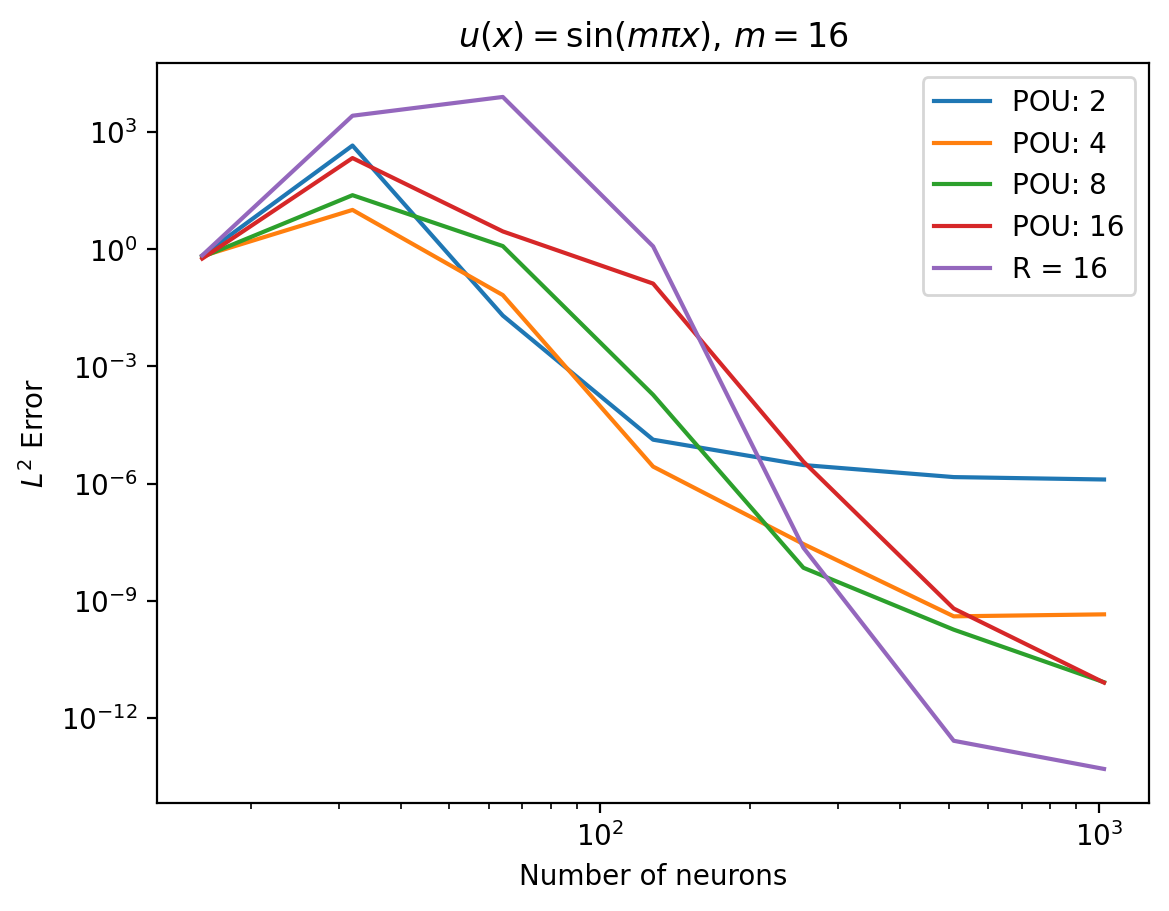

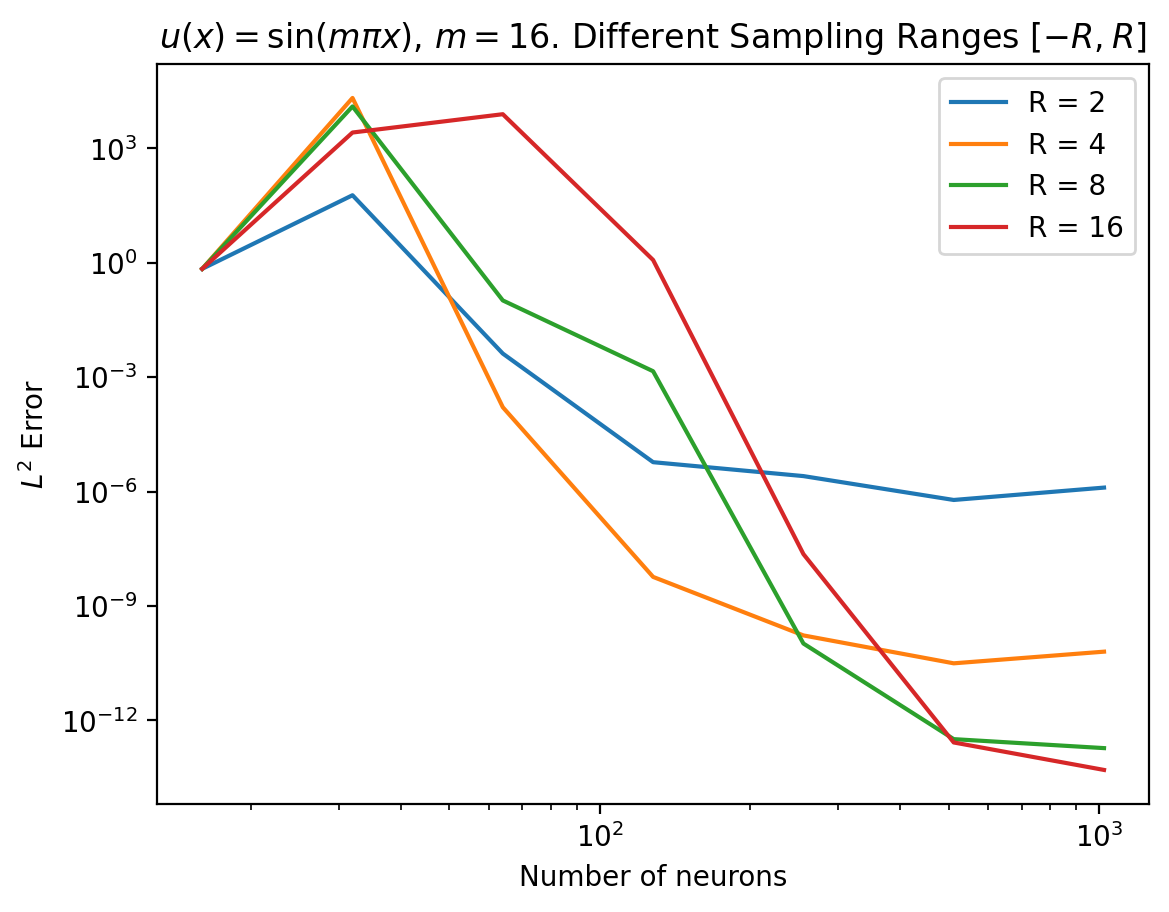

In [3]:
filename1 = "RFM_1dh1_noPOU_tanh_diff_Rm_sin16pix.pt"
filename2 = 'RFM_1dh1_Rm_1_errs_sin16pix.pt'
err_R_values = torch.load(filename1) 
err_POU_nums = torch.load(filename2) 
neuron_nums = [2**k for k in range(4,11)] 

# Plotting comparison between using POU and not using POU 
plt.figure(dpi = 200) 
plt.plot(neuron_nums[:], err_POU_nums[0,:], label = "POU: 2")
plt.plot(neuron_nums[:], err_POU_nums[1,:], label = "POU: 4")
plt.plot(neuron_nums[:], err_POU_nums[2,:], label = "POU: 8")
plt.plot(neuron_nums[:], err_POU_nums[3,:], label = "POU: 16") 
plt.plot(neuron_nums[:], err_R_values[3,:], label = "R = 16")

plt.yscale('log')
plt.xscale('log')
plt.xlabel("Number of neurons")
plt.ylabel("$L^2$ Error")
plt.title("$u(x) = \sin(m\pi x)$, $m =16$")
plt.legend()
plt.savefig("h11d-POU_vs_noPOU_sin16.png")


#Without using POU: Plotting comparison between different sampling ranges
plt.figure(dpi = 200) 

plt.plot(neuron_nums[:], err_R_values[0,:], label = "R = 2")
plt.plot(neuron_nums[:], err_R_values[1,:], label = "R = 4")
plt.plot(neuron_nums[:], err_R_values[2,:], label = "R = 8")
plt.plot(neuron_nums[:], err_R_values[3,:], label = "R = 16")

plt.yscale('log')
plt.xscale('log')
plt.xlabel("Number of neurons")
plt.ylabel("$L^2$ Error")
plt.title("$u(x) = \sin(m\pi x)$, $m =16$. Different Sampling Ranges $[-R, R]$")
plt.legend()
# plt.show()
plt.savefig("h11d_noPOU_diff_Rm_sin16.png")